<a href="https://colab.research.google.com/github/kridtapon/Mean-Reversion-CCI-Strategy/blob/main/Mean_Reversion_CCI_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.6/527.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.2 MB/s eta 0:00:00


In [ ]:
pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.56
    Uninstalling yfinance-0.2.56:
      Successfully uninstalled yfinance-0.2.56


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt

# Function to calculate Z-score for mean reversion strategy
def calculate_z_score(series, window=20):
    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    z_score = (series - mean) / std
    return z_score

# Function to calculate Commodity Channel Index (CCI)
def calculate_cci(df, window=20):
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3
    moving_average = typical_price.rolling(window=window).mean()
    mean_deviation = (typical_price - moving_average).abs().rolling(window=window).mean()
    cci = (typical_price - moving_average) / (0.015 * mean_deviation)
    return cci

# Define the stock symbol and time period
symbol = 'GDDY'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Calculate Z-score based on the closing price
df['Z'] = calculate_z_score(df['Close'], window=20)

# Calculate CCI
df['CCI'] = calculate_cci(df, window=20)

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Entry conditions
df['Entry'] = (df['Z'] < -2) & (df['CCI'] < -100)  # Buy when price is far below mean and CCI is below -100
df['Exit'] = (df['Z'] > 2) & (df['CCI'] > 100)  # Exit when price reverts toward mean and CCI is above 100

# Shift entries and exits to next bar
shifted_entries = df['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
shifted_exits = df['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

# Create portfolio using 'Open' prices
portfolio = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shifted_entries,
    exits=shifted_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()


[*********************100%***********************]  1 of 1 completed
<ipython-input-5-720a1ee0ca72>:43: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-5-720a1ee0ca72>:44: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Start                         2020-01-02 00:00:00
End                           2024-12-31 00:00:00
Period                         1258 days 00:00:00
Start Value                              100000.0
End Value                            315672.96653
Total Return [%]                       215.672967
Benchmark Return [%]                   190.187516
Max Gross Exposure [%]                      100.0
Total Fees Paid                       4234.641806
Max Drawdown [%]                        32.675576
Max Drawdown Duration           244 days 00:00:00
Total Trades                                   11
Total Closed Trades                            11
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            90.909091
Best Trade [%]                          23.606389
Worst Trade [%]                         -3.684901
Avg Winning Trade [%]                   12.813994
Avg Losing Trade [%]                    -3.684901


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
from itertools import product

# Function to calculate Z-score
def calculate_z_score(series, window):
    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    return (series - mean) / std

# Function to calculate CCI
def calculate_cci(df, window):
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    ma = tp.rolling(window=window).mean()
    md = (tp - ma).abs().rolling(window=window).mean()
    return (tp - ma) / (0.015 * md)

# Download data
symbol = 'GDDY'
start_date = '2019-01-01'
end_date = '2025-01-01'
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Define parameter search space
z_windows = range(10, 51, 10)
cci_windows = range(10, 51, 10)

# Track best result
best_result = None
best_params = None

# Optimization loop
for z_win, cci_win in product(z_windows, cci_windows):
    df['Z'] = calculate_z_score(df['Close'], z_win)
    df['CCI'] = calculate_cci(df, cci_win)

    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

    df_test['Entry'] = (df_test['Z'] < -2) & (df_test['CCI'] < -100)
    df_test['Exit'] = (df_test['Z'] > 2) & (df_test['CCI'] > 100)

    shifted_entries = df_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
    shifted_exits = df_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

    portfolio = vbt.Portfolio.from_signals(
        close=df_test['Open'],
        entries=shifted_entries,
        exits=shifted_exits,
        init_cash=100_000,
        fees=0.001,
        slippage=0.002,
        freq='D'
    )

    final_value = portfolio.stats()['Total Return [%]']

    if best_result is None or final_value > best_result:
        best_result = final_value
        best_params = (z_win, cci_win)

# Output best parameters
print(f"Best Z-score window: {best_params[0]}, Best CCI window: {best_params[1]}")
print(f"Best Total Return [%]: {best_result:.2f}")


[*********************100%***********************]  1 of 1 completed
<ipython-input-6-0bcaaaf7940e>:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-6-0bcaaaf7940e>:42: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-6-0bcaaaf7940e>:44: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

Best Z-score window: 20, Best CCI window: 10
Best Total Return [%]: 298.76


<ipython-input-6-0bcaaaf7940e>:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-6-0bcaaaf7940e>:42: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-6-0bcaaaf7940e>:44: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-6-0bcaaaf7940e>:45: FutureWarning:

Streaming output truncated to the last 5000 lines.
<ipython-input-8-99d71f15f3f2>:47: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-8-99d71f15f3f2>:48: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-8-99d71f15f3f2>:47: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-8-99d71f15f3f2>:48: FutureWarni

Best Z-score window: 16, Best CCI window: 16
Best Total Return [%]: 425.91


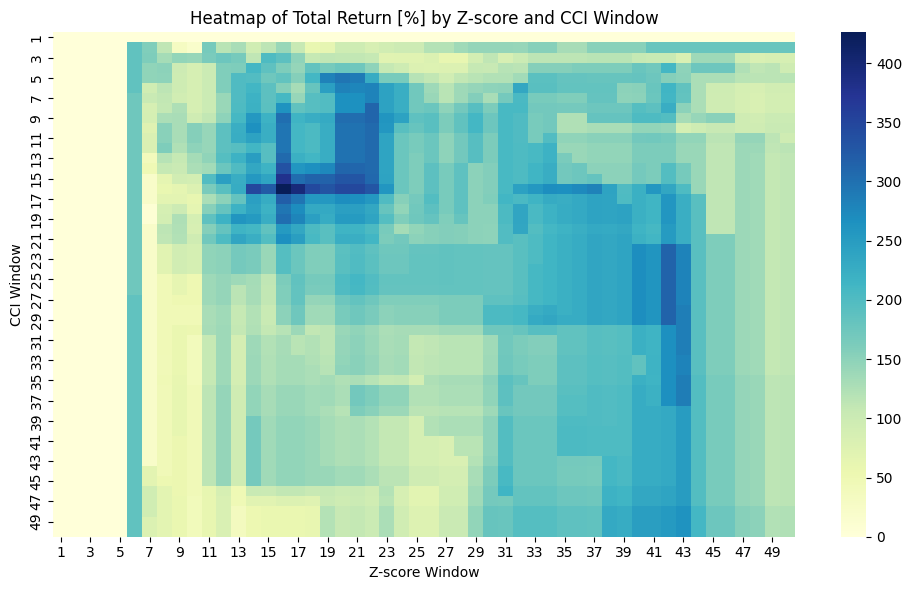

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate Z-score
def calculate_z_score(series, window):
    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    return (series - mean) / std

# Function to calculate CCI
def calculate_cci(df, window):
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    ma = tp.rolling(window=window).mean()
    md = (tp - ma).abs().rolling(window=window).mean()
    return (tp - ma) / (0.015 * md)

# Download data
symbol = 'GDDY'
start_date = '2019-01-01'
end_date = '2025-01-01'
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Define parameter search space
z_windows = range(1, 51)
cci_windows = range(1, 51)

# Track best result
best_result = None
best_params = None
results = []

# Optimization loop
for z_win, cci_win in product(z_windows, cci_windows):
    df['Z'] = calculate_z_score(df['Close'], z_win)
    df['CCI'] = calculate_cci(df, cci_win)

    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)].copy()

    df_test['Entry'] = (df_test['Z'] < -2) & (df_test['CCI'] < -100)
    df_test['Exit'] = (df_test['Z'] > 2) & (df_test['CCI'] > 100)

    shifted_entries = df_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
    shifted_exits = df_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

    portfolio = vbt.Portfolio.from_signals(
        close=df_test['Open'],
        entries=shifted_entries,
        exits=shifted_exits,
        init_cash=100_000,
        fees=0.001,
        slippage=0.002,
        freq='D'
    )

    total_return = portfolio.stats()['Total Return [%]']
    results.append((z_win, cci_win, total_return))

    if best_result is None or total_return > best_result:
        best_result = total_return
        best_params = (z_win, cci_win)

# Output best parameters
print(f"Best Z-score window: {best_params[0]}, Best CCI window: {best_params[1]}")
print(f"Best Total Return [%]: {best_result:.2f}")

# Create heatmap DataFrame
results_df = pd.DataFrame(results, columns=['Z_Window', 'CCI_Window', 'Total_Return'])
heatmap_df = results_df.pivot(index='CCI_Window', columns='Z_Window', values='Total_Return')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=False, fmt=".2f", cmap='YlGnBu')
plt.title("Heatmap of Total Return [%] by Z-score and CCI Window")
plt.xlabel("Z-score Window")
plt.ylabel("CCI Window")
plt.tight_layout()
plt.show()


In [ ]:
# Calculate Z-score based on the closing price
df['Z'] = calculate_z_score(df['Close'], window=16)

# Calculate CCI
df['CCI'] = calculate_cci(df, window=16)

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Entry conditions
df['Entry'] = (df['Z'] < -2) & (df['CCI'] < -100)  # Buy when price is far below mean and CCI is below -100
df['Exit'] = (df['Z'] > 2) & (df['CCI'] > 100)  # Exit when price reverts toward mean and CCI is above 100

# Shift entries and exits to next bar
shifted_entries = df['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
shifted_exits = df['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

# Create portfolio using 'Open' prices
portfolio = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shifted_entries,
    exits=shifted_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()

<ipython-input-9-1220e4b57e2f>:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-9-1220e4b57e2f>:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-9-1220e4b57e2f>:15: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-9-1220e4b57e2f>:16: FutureWarning:

Start                         2020-01-02 00:00:00
End                           2024-12-31 00:00:00
Period                         1258 days 00:00:00
Start Value                              100000.0
End Value                           525914.465774
Total Return [%]                       425.914466
Benchmark Return [%]                   190.187516
Max Gross Exposure [%]                      100.0
Total Fees Paid                       9387.768131
Max Drawdown [%]                        32.675576
Max Drawdown Duration           229 days 00:00:00
Total Trades                                   18
Total Closed Trades                            17
Total Open Trades                               1
Open Trade PnL                       -1578.795226
Win Rate [%]                            94.117647
Best Trade [%]                           20.97468
Worst Trade [%]                         -0.066983
Avg Winning Trade [%]                   11.123094
Avg Losing Trade [%]                    -0.066983


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


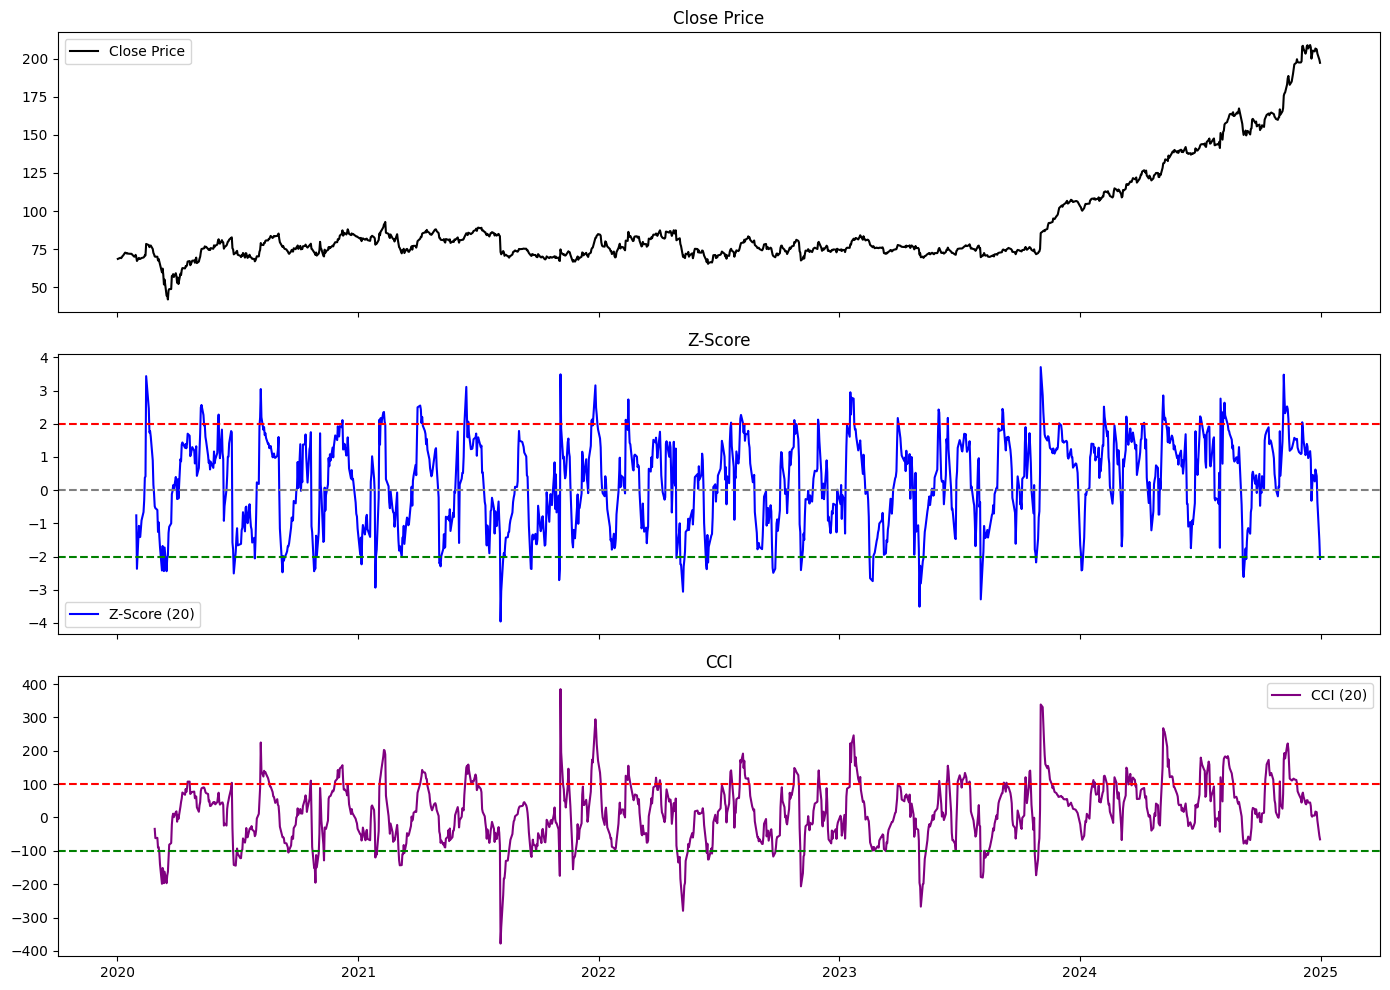

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Function to calculate Z-score
def calculate_z_score(series, window):
    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    return (series - mean) / std

# Function to calculate CCI
def calculate_cci(df, window):
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    ma = tp.rolling(window=window).mean()
    md = (tp - ma).abs().rolling(window=window).mean()
    return (tp - ma) / (0.015 * md)

# Download data
symbol = 'GDDY'
start_date = '2020-01-01'
end_date = '2025-01-01'
df = yf.download(symbol, start=start_date, end=end_date)

# Calculate indicators
z_window = 20
cci_window = 20
df['Z'] = calculate_z_score(df['Close'], z_window)
df['CCI'] = calculate_cci(df, cci_window)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Close Price
axes[0].plot(df.index, df['Close'], label='Close Price', color='black')
axes[0].set_title('Close Price')
axes[0].legend()

# Z-score
axes[1].plot(df.index, df['Z'], label=f'Z-Score ({z_window})', color='blue')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].axhline(2, color='red', linestyle='--')
axes[1].axhline(-2, color='green', linestyle='--')
axes[1].set_title('Z-Score')
axes[1].legend()

# CCI
axes[2].plot(df.index, df['CCI'], label=f'CCI ({cci_window})', color='purple')
axes[2].axhline(100, color='red', linestyle='--')
axes[2].axhline(-100, color='green', linestyle='--')
axes[2].set_title('CCI')
axes[2].legend()

plt.tight_layout()
plt.show()
